## 1) Setup

In [55]:
import random
import pandas as pd
import matplotlib.pyplot as plt

random.seed(42)

## 2) Simulate many dice experiments

We will:

* roll a die 20 times
* repeat the experiment 5000 times

In [56]:
random.randint(1,6)

6

In [57]:
for i in range(5,101,5):
    print(i)

5
10
15
20
25
30
35
40
45
50
55
60
65
70
75
80
85
90
95
100


In [58]:
list(range(10))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [59]:
def roll_die():
    return random.randint(1,6)

experiments = []

for _ in range(5000):              # repeat experiment many times
    rolls = []
    for _ in range(20):            # 20 rolls each experiment
        rolls.append(roll_die())
    experiments.append(rolls)

Convert to dataframe:

In [60]:
df = pd.DataFrame(experiments)

Each row = one experiment  
Each column = one roll

In [61]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1,1,6,3,2,2,2,6,1,6,6,5,1,5,4,1,1,1,2,2
1,5,5,1,5,2,6,6,6,5,4,2,4,5,3,1,2,6,4,3,3
2,2,2,3,1,1,4,1,3,3,5,3,1,6,4,5,1,4,1,5,3
3,6,5,3,5,2,6,1,1,6,2,3,1,2,1,4,3,4,6,3,2
4,3,3,2,6,3,6,6,6,1,5,6,2,5,6,2,2,4,4,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,4,1,2,3,5,2,1,1,5,6,3,6,2,3,6,6,5,4,2
4996,1,5,5,1,4,3,4,2,4,2,5,1,1,4,6,3,5,3,3,4
4997,2,2,6,3,3,3,6,1,6,3,2,4,1,4,3,4,5,1,3,3
4998,6,1,5,5,3,6,2,1,4,6,4,2,6,5,4,2,2,5,2,2


## 3) BINOMIAL WORLD — count sixes

We count how many times "6" appears in each experiment.

In [62]:
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1,1,6,3,2,2,2,6,1,6,6,5,1,5,4,1,1,1,2,2
1,5,5,1,5,2,6,6,6,5,4,2,4,5,3,1,2,6,4,3,3
2,2,2,3,1,1,4,1,3,3,5,3,1,6,4,5,1,4,1,5,3
3,6,5,3,5,2,6,1,1,6,2,3,1,2,1,4,3,4,6,3,2
4,3,3,2,6,3,6,6,6,1,5,6,2,5,6,2,2,4,4,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,4,1,2,3,5,2,1,1,5,6,3,6,2,3,6,6,5,4,2
4996,1,5,5,1,4,3,4,2,4,2,5,1,1,4,6,3,5,3,3,4
4997,2,2,6,3,3,3,6,1,6,3,2,4,1,4,3,4,5,1,3,3
4998,6,1,5,5,3,6,2,1,4,6,4,2,6,5,4,2,2,5,2,2


In [63]:
(df==6)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,True,True,True,False,False,False,False,False,False,False,False,True,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,True,False,True,True,True,False,False,True,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,True,False,False,False
4996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4997,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False
4998,True,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False


In [64]:
(df==6).sum(axis=1)

0       4
1       4
2       1
3       4
4       7
       ..
4995    4
4996    1
4997    3
4998    4
4999    4
Length: 5000, dtype: int64

In [65]:
df["num_sixes"] = (df == 6).sum(axis=1)

df["num_sixes"]

0       4
1       4
2       1
3       4
4       7
       ..
4995    4
4996    1
4997    3
4998    4
4999    4
Name: num_sixes, Length: 5000, dtype: int64

In [66]:
df

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,num_sixes
0,1,1,6,3,2,2,2,6,1,6,...,5,1,5,4,1,1,1,2,2,4
1,5,5,1,5,2,6,6,6,5,4,...,4,5,3,1,2,6,4,3,3,4
2,2,2,3,1,1,4,1,3,3,5,...,1,6,4,5,1,4,1,5,3,1
3,6,5,3,5,2,6,1,1,6,2,...,1,2,1,4,3,4,6,3,2,4
4,3,3,2,6,3,6,6,6,1,5,...,2,5,6,2,2,4,4,3,6,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,4,1,2,3,5,2,1,1,5,...,3,6,2,3,6,6,5,4,2,4
4996,1,5,5,1,4,3,4,2,4,2,...,1,1,4,6,3,5,3,3,4,1
4997,2,2,6,3,3,3,6,1,6,3,...,4,1,4,3,4,5,1,3,3,3
4998,6,1,5,5,3,6,2,1,4,6,...,2,6,5,4,2,2,5,2,2,4


Plot:

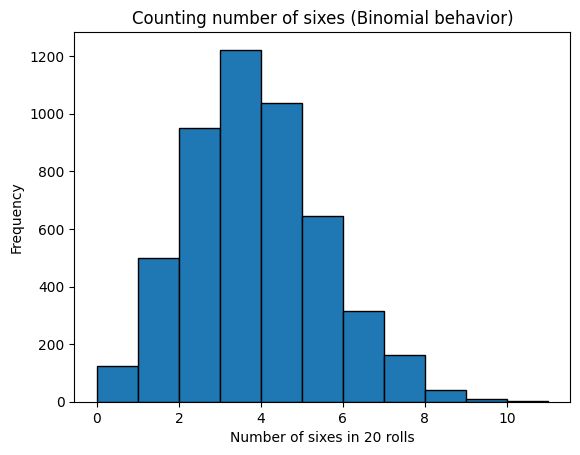

In [67]:
plt.hist(df["num_sixes"], bins=range(0,12), edgecolor="black")
plt.title("Counting number of sixes (Binomial behavior)")
plt.xlabel("Number of sixes in 20 rolls")
plt.ylabel("Frequency")
plt.show()

You should see **spiky bars**.

You care about exact counts:

> 2 sixes vs 3 sixes matters a lot

## 4) LESS DISCRETE — count evens

Now success = even number (2,4,6)

In [68]:
df.columns

Index([          0,           1,           2,           3,           4,
                 5,           6,           7,           8,           9,
                10,          11,          12,          13,          14,
                15,          16,          17,          18,          19,
       'num_sixes'],
      dtype='object')

In [69]:
roll_cols = df.columns[:20]


In [70]:
# subsetting the dataframe to just the rolls
df[roll_cols]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1,1,6,3,2,2,2,6,1,6,6,5,1,5,4,1,1,1,2,2
1,5,5,1,5,2,6,6,6,5,4,2,4,5,3,1,2,6,4,3,3
2,2,2,3,1,1,4,1,3,3,5,3,1,6,4,5,1,4,1,5,3
3,6,5,3,5,2,6,1,1,6,2,3,1,2,1,4,3,4,6,3,2
4,3,3,2,6,3,6,6,6,1,5,6,2,5,6,2,2,4,4,3,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,4,1,2,3,5,2,1,1,5,6,3,6,2,3,6,6,5,4,2
4996,1,5,5,1,4,3,4,2,4,2,5,1,1,4,6,3,5,3,3,4
4997,2,2,6,3,3,3,6,1,6,3,2,4,1,4,3,4,5,1,3,3
4998,6,1,5,5,3,6,2,1,4,6,4,2,6,5,4,2,2,5,2,2


In [71]:
10 % 2 == 0

True

In [72]:
df[roll_cols] % 2 

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,1,1,0,1,0,0,0,0,1,0,0,1,1,1,0,1,1,1,0,0
1,1,1,1,1,0,0,0,0,1,0,0,0,1,1,1,0,0,0,1,1
2,0,0,1,1,1,0,1,1,1,1,1,1,0,0,1,1,0,1,1,1
3,0,1,1,1,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1,0
4,1,1,0,0,1,0,0,0,1,1,0,0,1,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,0,1,0,1,1,0,1,1,1,0,1,0,0,1,0,0,1,0,0
4996,1,1,1,1,0,1,0,0,0,0,1,1,1,0,0,1,1,1,1,0
4997,0,0,0,1,1,1,0,1,0,1,0,0,1,0,1,0,1,1,1,1
4998,0,1,1,1,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0


In [73]:
df[roll_cols] % 2 == 0

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,False,False,True,False,True,True,True,True,False,True,True,False,False,False,True,False,False,False,True,True
1,False,False,False,False,True,True,True,True,False,True,True,True,False,False,False,True,True,True,False,False
2,True,True,False,False,False,True,False,False,False,False,False,False,True,True,False,False,True,False,False,False
3,True,False,False,False,True,True,False,False,True,True,False,False,True,False,True,False,True,True,False,True
4,False,False,True,True,False,True,True,True,False,False,True,True,False,True,True,True,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,False,True,False,True,False,False,True,False,False,False,True,False,True,True,False,True,True,False,True,True
4996,False,False,False,False,True,False,True,True,True,True,False,False,False,True,True,False,False,False,False,True
4997,True,True,True,False,False,False,True,False,True,False,True,True,False,True,False,True,False,False,False,False
4998,True,False,False,False,False,True,True,False,True,True,True,True,True,False,True,True,True,False,True,True


In [74]:

df["num_evens"] = (df[roll_cols] % 2 == 0).sum(axis=1)


In [75]:
df

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,num_sixes,num_evens
0,1,1,6,3,2,2,2,6,1,6,...,1,5,4,1,1,1,2,2,4,10
1,5,5,1,5,2,6,6,6,5,4,...,5,3,1,2,6,4,3,3,4,10
2,2,2,3,1,1,4,1,3,3,5,...,6,4,5,1,4,1,5,3,1,6
3,6,5,3,5,2,6,1,1,6,2,...,2,1,4,3,4,6,3,2,4,10
4,3,3,2,6,3,6,6,6,1,5,...,5,6,2,2,4,4,3,6,7,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,4,1,2,3,5,2,1,1,5,...,6,2,3,6,6,5,4,2,4,10
4996,1,5,5,1,4,3,4,2,4,2,...,1,4,6,3,5,3,3,4,1,8
4997,2,2,6,3,3,3,6,1,6,3,...,1,4,3,4,5,1,3,3,3,9
4998,6,1,5,5,3,6,2,1,4,6,...,6,5,4,2,2,5,2,2,4,13


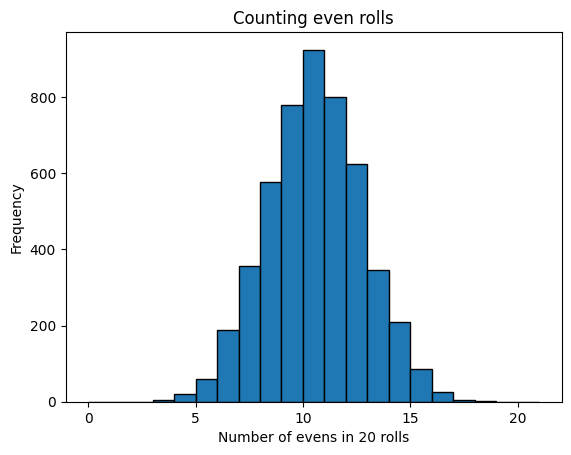

In [76]:

plt.hist(df["num_evens"], bins=range(0,22), edgecolor="black")
plt.title("Counting even rolls")
plt.xlabel("Number of evens in 20 rolls")
plt.ylabel("Frequency")
plt.show()

Now the shape looks like a **hill**

Still counts… but smoother.

## 5) NORMAL WORLD — average roll

Now instead of counting events, we measure the average value.

In [77]:
roll_cols

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='object')

In [78]:
df["avg_roll"] = df[roll_cols].mean(axis=1)


In [79]:
df

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,num_sixes,num_evens,avg_roll
0,1,1,6,3,2,2,2,6,1,6,...,5,4,1,1,1,2,2,4,10,2.90
1,5,5,1,5,2,6,6,6,5,4,...,3,1,2,6,4,3,3,4,10,3.90
2,2,2,3,1,1,4,1,3,3,5,...,4,5,1,4,1,5,3,1,6,2.90
3,6,5,3,5,2,6,1,1,6,2,...,1,4,3,4,6,3,2,4,10,3.30
4,3,3,2,6,3,6,6,6,1,5,...,6,2,2,4,4,3,6,7,13,4.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,5,4,1,2,3,5,2,1,1,5,...,2,3,6,6,5,4,2,4,10,3.60
4996,1,5,5,1,4,3,4,2,4,2,...,4,6,3,5,3,3,4,1,8,3.30
4997,2,2,6,3,3,3,6,1,6,3,...,4,3,4,5,1,3,3,3,9,3.25
4998,6,1,5,5,3,6,2,1,4,6,...,5,4,2,2,5,2,2,4,13,3.65


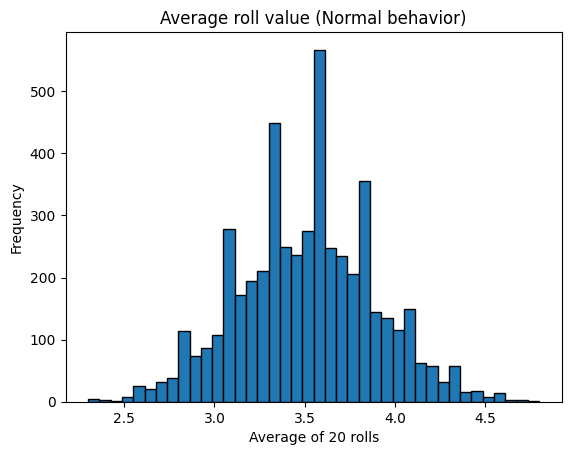

In [80]:

plt.hist(df["avg_roll"], bins=40, edgecolor="black")
plt.title("Average roll value (Normal behavior)")
plt.xlabel("Average of 20 rolls")
plt.ylabel("Frequency")
plt.show()

Now you should see a **smoother bell curve**

Same dice  
Same randomness  
Different question

## 6) Key Comparison

Print summary:

In [81]:
print("Average of averages:", df["avg_roll"].mean())
print("Spread of averages:", df["avg_roll"].std())

Average of averages: 3.5057100000000005
Spread of averages: 0.37817522287934197


You'll notice:  
The averages cluster tightly around ~3.5

## What you just demonstrated

You did NOT change randomness.

You changed what you measured:

| Measurement  | Behavior          |
| ------------ | ----------------- |
| count sixes  | binomial          |
| count evens  | binomial-ish hill |
| average roll | normal            |

## If you want a nice extension

Increase number of rolls to 100:

```python
# change 20 → 100 above and rerun
```

The bell curve becomes tighter.

That is the entire foundation of statistics.

---

## Poisson — random arrivals in time

Now we simulate a different kind of randomness using the same dice.

Instead of a fixed number of rolls, rolls happen randomly over time:

> "How many sixes happen in 1 minute of random rolling?"

We don't pre-decide the number of rolls.  
Rolls arrive randomly, and that's the key difference from binomial.

## Idea of the simulation

Real life:

* You roll continuously
* Sometimes quickly, sometimes slower
* Each moment has a small chance a roll happens
* Each roll has a chance to be a 6

We will simulate time passing in tiny steps.

Every tiny moment:

1. maybe a roll happens
2. if a roll happens → maybe it is a 6

This produces **random arrivals**, which is exactly Poisson behavior.

## 2) Simulate one minute

Instead of looping through tiny time slices, we can simulate this more directly:

1. Draw the number of rolls from a Poisson distribution (average ~120 rolls per minute)
2. Roll the die that many times and count sixes

This captures the same idea — the number of opportunities is itself random.

In [82]:
# this is NOT using list comprehension
a = []
for i in range(5):
    a.append(i)

a

[0, 1, 2, 3, 4]

In [83]:
# this IS using list comprehension
b = [i for i in range(5)]
b

[0, 1, 2, 3, 4]

In [84]:
# this IS using list comprehension
b = [(i+1)*3 for i in range(5)]
b

[3, 6, 9, 12, 15]

In [105]:
import numpy as np

def simulate_one_minute():
    num_rolls = np.random.poisson(lam=120)  # random number of rolls in a minute
    rolls = [random.randint(1,6) for _ in range(num_rolls)]
    return rolls.count(6)


In [106]:
# count of how many times 6 appears in one minute of rolling
simulate_one_minute()

20

In [107]:
def simulate_one_minute(val):
    num_rolls = np.random.poisson(lam=120)  # random number of rolls in a minute
    rolls = [random.randint(1,6) for _ in range(num_rolls)]
    return rolls.count(val)


In [108]:
# count of how many times 3 appears in one minute of rolling
print(simulate_one_minute(3))
print(simulate_one_minute(6))

# Note probability of 3 and 6 should be the same, but we will see some variation due to randomness

19
15


In [109]:
rolls = []
num_rolls = np.random.poisson(lam=120)  # random number of rolls in a minute

for i in range(num_rolls):
    rolls.append(random.randint(1,6))

len(rolls)

105

In [110]:
num_rolls = np.random.poisson(lam=120)  # random number of rolls in a minute
num_rolls


103

In [111]:
rolls = [random.randint(1,6) for _ in range(num_rolls)]


In [112]:
np.random.poisson?

Signature: np.random.poisson(lam=1.0, size=None)
Docstring:
poisson(lam=1.0, size=None)

Draw samples from a Poisson distribution.

The Poisson distribution is the limit of the binomial distribution
for large N.

.. note::
    New code should use the `~numpy.random.Generator.poisson`
    method of a `~numpy.random.Generator` instance instead;
    please see the :ref:`random-quick-start`.

Parameters
----------
lam : float or array_like of floats
    Expected number of events occurring in a fixed-time interval,
    must be >= 0. A sequence must be broadcastable over the requested
    size.
size : int or tuple of ints, optional
    Output shape.  If the given shape is, e.g., ``(m, n, k)``, then
    ``m * n * k`` samples are drawn.  If size is ``None`` (default),
    a single value is returned if ``lam`` is a scalar. Otherwise,
    ``np.array(lam).size`` samples are drawn.

Returns
-------
out : ndarray or scalar
    Drawn samples from the parameterized Poisson distribution.

See Also
---

## 3) Repeat the experiment many times

We simulate many different minutes.

In [113]:
results = []

for _ in range(5000):
    results.append(simulate_one_minute(6))

df = pd.DataFrame({"sixes_per_minute": results})
df

,sixes_per_minute
0,22
1,20
2,13
3,14
4,16
...,...
4995,16
4996,11
4997,19
4998,22


In [114]:
df

,sixes_per_minute
0,22
1,20
2,13
3,14
4,16
...,...
4995,16
4996,11
4997,19
4998,22


## 4) Plot the distribution

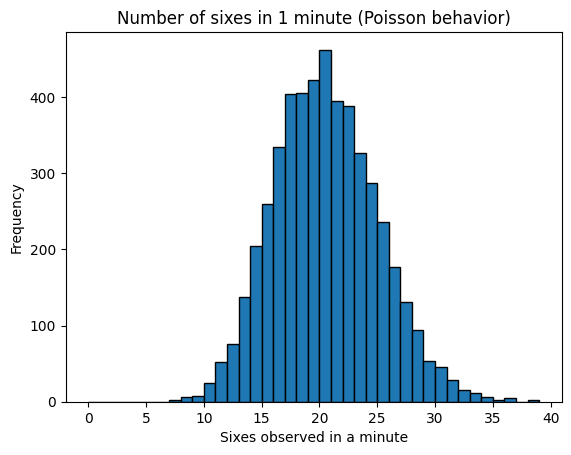

In [116]:
plt.hist(df["sixes_per_minute"], bins=range(0,40), edgecolor="black")
plt.title("Number of sixes in 1 minute (Poisson behavior)")
plt.xlabel("Sixes observed in a minute")
plt.ylabel("Frequency")
plt.show()

Step 1

Number of rolls per minute ≈ 120 on average

Step 2

Each roll has 1/6 chance of six

So expected sixes:

120 × (1/6) ≈ 20


Poisson(λ ≈ 20)


You should see:

* many small values
* few large values
* skewed right
* not symmetric

That's Poisson.

## 5) Compare to binomial (fixed rolls)

Now contrast it with a fixed number of rolls (old world).

Exactly 120 rolls every time:

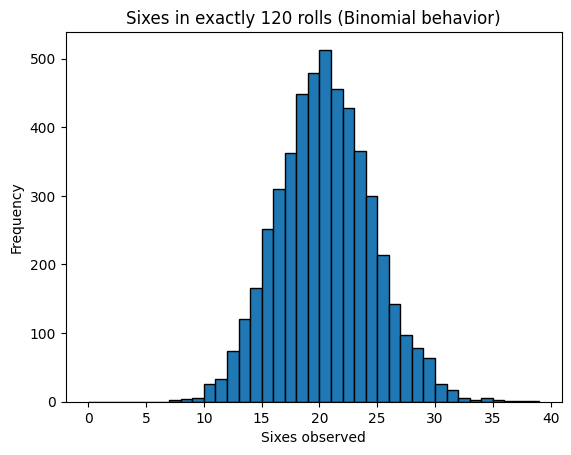

In [96]:
def fixed_rolls():
    count = 0
    for _ in range(120):
        if random.randint(1,6) == 6:
            count += 1
    return count

binomial_results = [fixed_rolls() for _ in range(5000)]

plt.hist(binomial_results, bins=range(0,40), edgecolor="black")
plt.title("Sixes in exactly 120 rolls (Binomial behavior)")
plt.xlabel("Sixes observed")
plt.ylabel("Frequency")
plt.show()

This one becomes more bell-shaped.

## What you just observed

| Situation               | Distribution |
| ----------------------- | ------------ |
| fixed number of rolls   | binomial     |
| random arrivals in time | poisson      |

Same dice  
Same probability  
Different structure of randomness

## The intuition

Poisson appears when:

> events occur randomly over time without a fixed number of attempts

You didn't count trials — you counted arrivals.

## One-sentence memory trick

**Binomial** = "Out of how many tries?"  
**Poisson** = "During how long?"

---

## Negative Binomial — count attempts to reach a goal

You now have two mental models:

* **Binomial** → fixed number of rolls → count successes
* **Poisson** → fixed time → count arrivals

The negative binomial flips the question:

> **Fixed number of successes → count how many attempts it takes**

It's not time-based and not trial-based. It's **goal-based** — you stop when you reach a target.

## Stay in the same dice universe 🎲

We keep:

> success = rolling a 6

But now the rule changes:

Instead of rolling 20 times  
or rolling for 1 minute

You say:

> "I will keep rolling until I get 5 sixes."

You don't know how many rolls it will take.

Sometimes lucky:

```
6,2,6,6,3,1,6,4,6   → only 9 rolls
```

Sometimes unlucky:

```
2,3,4,1,5,2,3,1,4,2,5,1,3,4,2,5,6,... → maybe 40 rolls
```

You record:

> number of rolls required to reach 5 successes

Repeat experiment many times.

You'll see:

```
8, 14, 21, 9, 17, 35, 12, 18, 10...
```

Plot that → right-skewed shape.

That is the **negative binomial distribution**

## Intuition

Instead of asking:

> How many successes happen?

You ask:

> How much effort until success?

This appears everywhere in real life:

* number of customers contacted before making 3 sales
* number of experiments before 2 successful results
* number of shots before scoring 1 goal

You stop when goal achieved.

## Comparison (important)

| Distribution      | What is fixed | What varies       |
| ----------------- | ------------- | ----------------- |
| Binomial          | attempts      | successes         |
| Poisson           | time          | arrivals          |
| Negative Binomial | successes     | attempts required |

This is the cleanest way to remember it.

## Now let's simulate it in Python

### 2) Function: rolls needed to get 5 sixes

In [97]:
def rolls_until_n_sixes(n):
    # represent how many sixes we have rolled so far
    sixes = 0
    # represent how many rolls we have rolled so far
    rolls = 0
    
    while sixes < n:

        # increment rolls by 1 for each roll
        rolls += 1
        # This is the simulation of the roll
        if random.randint(1,6) == 6:
            
            # increment sixes by 1 if we rolled a 6
            sixes += 1

    # how many rolls did it take to get n sixes? 
    return rolls

In [117]:
# increment operator example
a = 0
a += 1  # this is the same as a = a + 1
a

1

### 3) Repeat many experiments

In [123]:
THRESHOLD = 1
results = []

for _ in range(5000):
    results.append(rolls_until_n_sixes(n=THRESHOLD))

df = pd.DataFrame({"rolls_needed": results})
df

,rolls_needed
0,9
1,8
2,8
3,5
4,5
...,...
4995,2
4996,2
4997,11
4998,1


### 4) Plot distribution

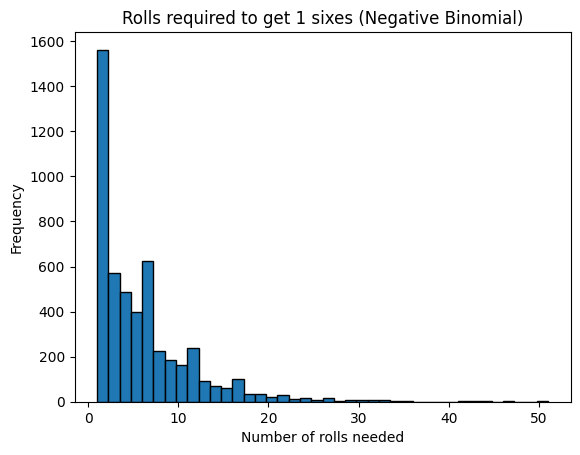

In [124]:
plt.hist(df["rolls_needed"], bins=40, edgecolor="black")
plt.title(f"Rolls required to get {THRESHOLD} sixes (Negative Binomial)")
plt.xlabel("Number of rolls needed")
plt.ylabel("Frequency")
plt.show()

You will see:

* cannot be small (minimum = 5)
* long right tail
* skewed distribution

## Why it's called *negative* binomial

Because it is basically the reverse question of binomial:

Binomial:

> successes after fixed rolls

Negative binomial:

> rolls after fixed successes

They are mathematical inverses.

## One-sentence intuition

Binomial counts wins in fixed effort.  
Negative binomial measures effort to reach fixed wins.

## Final mental map

Think of a video game:

| Question                                     | Distribution      |
| -------------------------------------------- | ----------------- |
| How many enemies defeated in 30 attacks?     | Binomial          |
| How many enemies appear in 1 minute?         | Poisson           |
| How many attacks until defeating 10 enemies? | Negative Binomial |

## Geometric Distribution

Geometric is the simplest member of this family.

Negative binomial asks: "How many rolls until I get 5 sixes?"

Now shrink the goal to just one.

## Geometric Distribution (same dice world 🎲)

Keep everything identical:

> success = rolling a 6

But now the rule:

> "Keep rolling until the FIRST six appears."

That's it.

You stop immediately when success happens.

## Run a few experiments mentally

```
6 → took 1 roll
3,6 → took 2 rolls
2,5,1,4,3,6 → took 6 rolls
1,2,3,4,5,1,2,3,4,5,6 → took 11 rolls
```

Record only:

> number of rolls needed to get first six

Repeat many times:

```
1, 2, 4, 1, 7, 3, 12, 2, 1, 5, 3, 20, 6...
```

Plot → sharply right-skewed

That's the **geometric distribution**

## What makes it special?

You don't care about multiple successes.

You only care about:

> waiting time until the first success

It's the most basic "waiting" randomness.

## Relationship to negative binomial

Negative binomial:

> rolls until 5 successes

Geometric:

> rolls until 1 success

So:

> geometric = negative binomial with goal = 1

## Intuition

Geometric models **patience**.

Examples:

* how many calls until first sale
* how many attempts until first bug found
* how many shots until first goal
* how many swipes until first match 😄

You don't fix effort or time.  
You wait until something finally works.

## Python simulation

### 2) Function: rolls until first six

In [120]:
def rolls_until_first_six():
    rolls = 0
    
    while True:
        rolls += 1
        if random.randint(1,6) == 6:
            return rolls

### 3) Repeat experiment many times

In [121]:
results = []

for _ in range(5000):
    results.append(rolls_until_first_six())

df = pd.DataFrame({"rolls_needed": results})
df.head()

,rolls_needed
0,3
1,1
2,3
3,2
4,5


### 4) Plot distribution

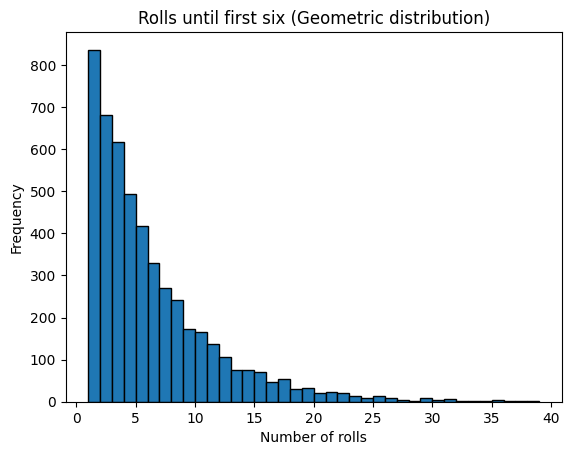

In [122]:
plt.hist(df["rolls_needed"], bins=range(1,40), edgecolor="black")
plt.title("Rolls until first six (Geometric distribution)")
plt.xlabel("Number of rolls")
plt.ylabel("Frequency")
plt.show()

You should see:

* very tall bar at 1
* rapidly decreasing probabilities
* long tail

## The cool property (very important intuition)

Suppose you already rolled 10 times and still no six.

What are your chances on the next roll?

Still **exactly the same** as always.

Past failures don't matter.

This is called the **memoryless property**.

Only geometric (and exponential in continuous time) behaves this way.

## Clean comparison (final map)

| Distribution      | Dice Question                    |
| ----------------- | -------------------------------- |
| Binomial          | How many sixes in 20 rolls?      |
| Poisson           | How many sixes in 1 minute?      |
| Negative Binomial | How many rolls to get 5 sixes? (i.e counting failures until first "success")  |
| Geometric         | How many rolls to get first six? |

## One-sentence intuition

Geometric measures waiting for the first success.  
Negative binomial measures waiting for several successes.